## Evaluieren des Modells

- Dazu wurde ein kleiner Testdatensatz (15 Bilder mit ca. 230 Instanzen) erstellt, dieser beinhaltet Textzeilen und mathematische Ausdrücke

In [1]:
!pip install ultralytics==8.4.15

## Laden der Modelle:
- own_and_iam_model: Das Modell, welches in Kombination des IAM und eigenen Datensatzes trainiert wurde
- only_own_model: Das Modell, welches nur auf den eigenen Datensatz trainiert wurde
- no_aug_own_and_iam_model: Das Modell, welches in Kombination des IAM und eigenen Datensatzes, aber ohne Datenaugmentierung trainiert wurde

In [4]:
from ultralytics import YOLO
own_and_iam_model = YOLO("runs/segment/new_own_trained_mixed/own_data_model_yolo11-l_default_febr_24/weights/best.pt")
only_own_model = YOLO("runs/segment/new_own_trained_125_models/own_data_model_yolo11-l_def_febr_24/weights/best.pt")
no_aug_own_and_iam_model = YOLO("runs/segment/new_own_trained_mixed/own_data_model_yolo11-l_def_febr_24_no_aug/weights/best.pt")

## Evaluierung (IAM + OWN):

In [5]:
own_and_iam_model = own_and_iam_model.val(data="test_dataset.yaml",split="test")

Ultralytics 8.4.15 🚀 Python-3.11.6 torch-2.4.0+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,134 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 30.3±28.2 MB/s, size: 1511.8 KB)
val: Scanning /home/dedol002/final_yolo/test_mixed.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3s/it 3.3s
                   all         15        234       0.91      0.869      0.932        0.8      0.914      0.873      0.935      0.656
              Textline         14        106      0.921      0.906      0.949      0.818      0.921      0.906      0.949      0.674
               Formula         15        128      0.899      0.832      0.914      0.781      0.907       0.84      0.921      0.637
Speed: 5.1ms preprocess, 18.3m

## Evaluierung (OWN):

In [6]:
only_own_model = only_own_model.val(data="test_dataset.yaml",split="test")

Ultralytics 8.4.15 🚀 Python-3.11.6 torch-2.4.0+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,134 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 282.4±404.4 MB/s, size: 707.7 KB)
val: Scanning /home/dedol002/final_yolo/test_mixed.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6s/it 2.6s
                   all         15        234      0.919       0.86      0.923      0.753      0.894      0.883      0.922      0.631
              Textline         14        106      0.918      0.915      0.922       0.73      0.875      0.922      0.921      0.634
               Formula         15        128       0.92      0.805      0.923      0.775      0.914      0.844      0.923      0.628
Speed: 5.2ms preprocess, 15.2

## Evaluierung (IAM + OWN + no_aug):

In [7]:
no_aug_own_and_iam_model = no_aug_own_and_iam_model.val(data="test_dataset.yaml",split="test")

Ultralytics 8.4.15 🚀 Python-3.11.6 torch-2.4.0+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,134 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 673.1±366.8 MB/s, size: 2356.9 KB)
val: Scanning /home/dedol002/final_yolo/test_mixed.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 2.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6s/it 2.6s
                   all         15        234      0.791       0.68      0.743      0.561      0.791       0.68      0.743      0.486
              Textline         14        106      0.763      0.736      0.733      0.547      0.763      0.736       0.74      0.487
               Formula         15        128       0.82      0.625      0.754      0.575       0.82      0.625      0.745      0.486
Speed: 4.8ms preprocess, 14.

## Visueller Test


0: 1280x960 11 Textlines, 7 Formulas, 64.1ms
Speed: 8.3ms preprocess, 64.1ms inference, 5.3ms postprocess per image at shape (1, 3, 1280, 960)


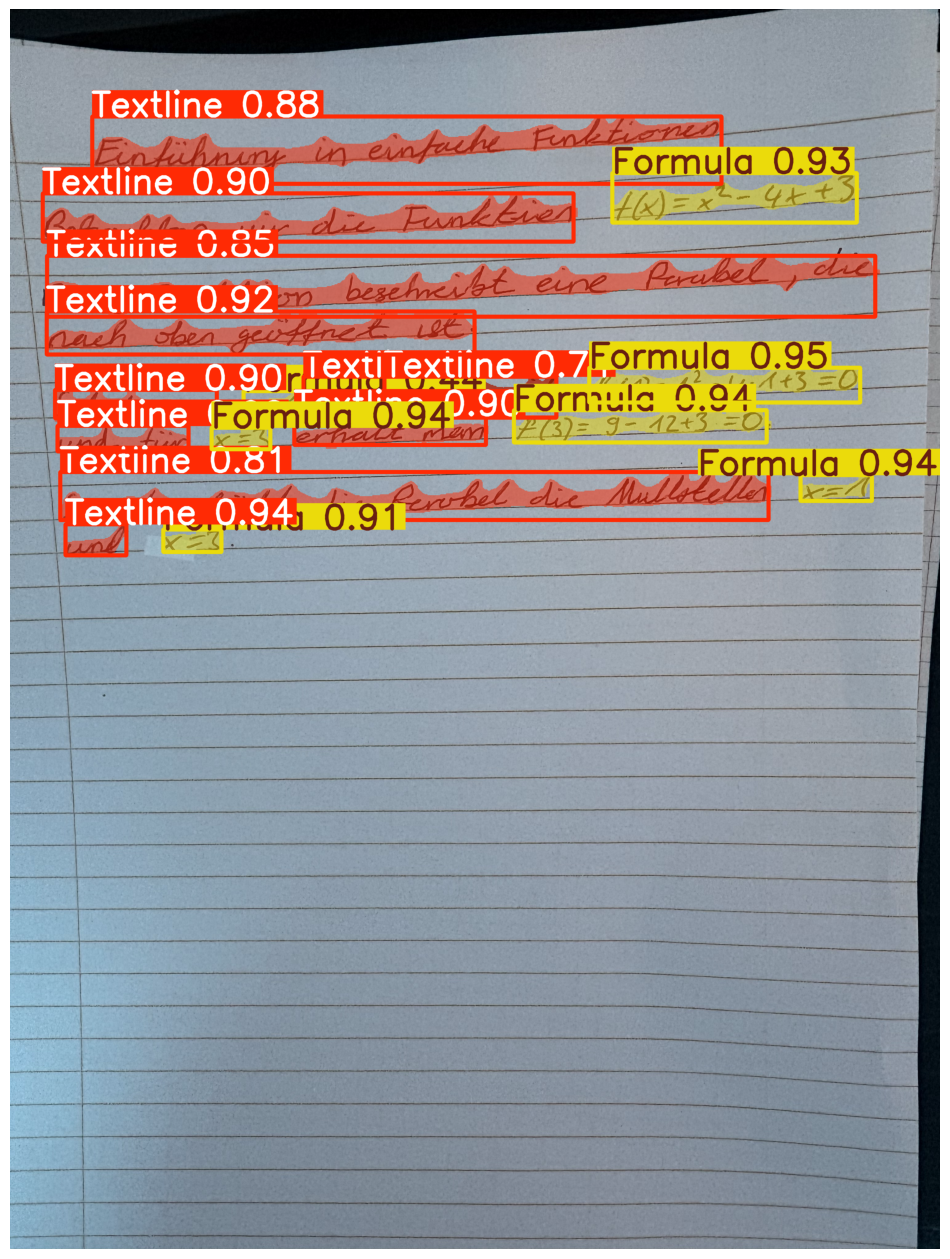

In [8]:
import cv2

from ultralytics import YOLO
trained_model = YOLO("runs/segment/new_own_trained_mixed/own_data_model_yolo11-l_default_febr_24/weights/best.pt")

img_path = "test_mixed/IMG_mixed_1.jpeg"
img = cv2.imread(img_path)

# Vorhersage
results = trained_model.predict(source=img, conf=0.3, iou=0.7, agnostic_nms=True)
#results = trained_model.predict(source=img, imgsz=1024)
%matplotlib inline
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 18))  
plt.imshow(results[0].plot())
plt.axis("off")
plt.show()